In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# In sklearn: 0 = malignant, 1 = benign. Recode so 1 = malignant (the class we care about).
df["target"] = 1 - df["target"]
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df["target"].map({0:"Benign",1:"Malignant"}).value_counts(normalize=True).round(3))
df.describe().T.head(10)

Missing values: 0
Duplicate rows: 0

Class balance:
target
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


/tmp/ipykernel_2196/2591255839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["target"].map({0:"Benign",1:"Malignant"}), y="mean radius", ax=ax[1], palette=["#4C9F70","#D1495B"])


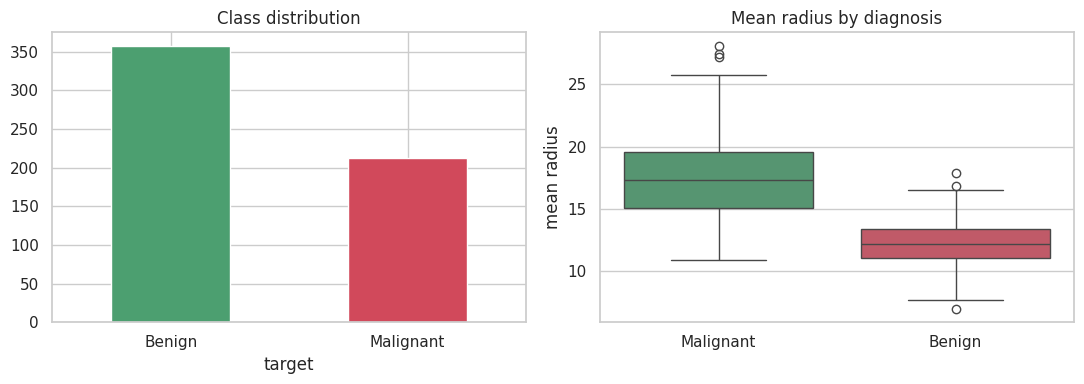

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["target"].map({0:"Benign",1:"Malignant"}).value_counts().plot.bar(ax=ax[0], color=["#4C9F70","#D1495B"])
ax[0].set_title("Class distribution"); ax[0].tick_params(axis="x", rotation=0)
sns.boxplot(data=df, x=df["target"].map({0:"Benign",1:"Malignant"}), y="mean radius", ax=ax[1], palette=["#4C9F70","#D1495B"])
ax[1].set_title("Mean radius by diagnosis"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

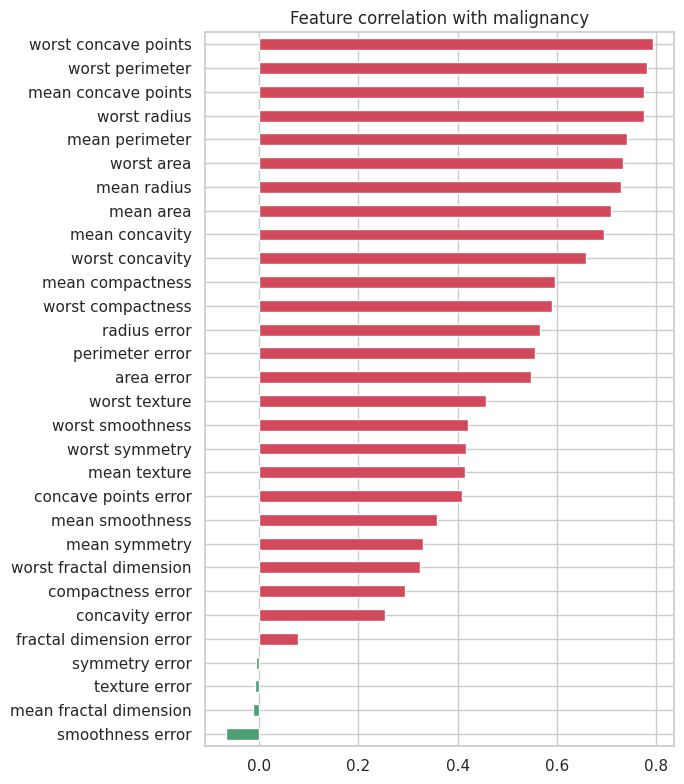

In [5]:
# Which features separate the classes most? (correlation with target)
corr_t = df.corr()["target"].drop("target").sort_values()
plt.figure(figsize=(7, 8))
corr_t.plot.barh(color=np.where(corr_t > 0, "#D1495B", "#4C9F70"))
plt.title("Feature correlation with malignancy"); plt.tight_layout(); plt.show()

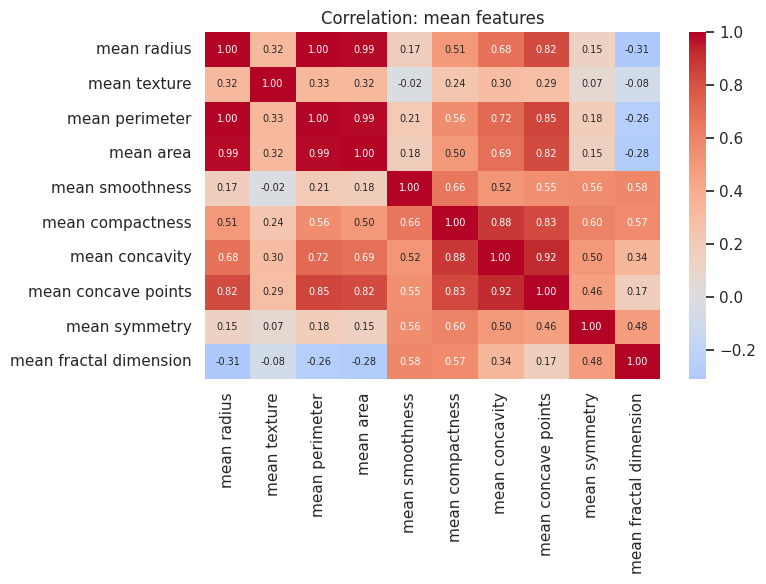

In [6]:
# Multicollinearity check
mean_cols = [c for c in df.columns if c.startswith("mean")]
plt.figure(figsize=(8, 6))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size":7})
plt.title("Correlation: mean features"); plt.tight_layout(); plt.show()

In [7]:
X = df.drop(columns="target"); y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [8]:
models = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "SVM (RBF)":           Pipeline([("sc", StandardScaler()), ("m", SVC(probability=True, random_state=RANDOM_STATE))]),
    "Random Forest":       Pipeline([("m", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
    "Gradient Boosting":   Pipeline([("m", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, pipe in models.items():
    rec = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="recall")
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    rows.append({"Model":name, "Recall":rec.mean(), "F1":f1.mean(), "ROC-AUC":auc.mean()})
cv_results = pd.DataFrame(rows).set_index("Model").round(4).sort_values("F1", ascending=False)
cv_results

,Recall,F1,ROC-AUC
Model,,,
Logistic Regression,0.9529,0.9640,0.9958
SVM (RBF),0.9471,0.9610,0.9949
Gradient Boosting,0.9471,0.9553,0.9908
Random Forest,0.9353,0.9461,0.9880


In [9]:
param_grid = {
    "m__C": [0.01, 0.1, 1, 10, 100],
    "m__gamma": ["scale", 0.01, 0.1],
}
grid = GridSearchCV(models["SVM (RBF)"], param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))
best_model = grid.best_estimator_

Best params: {'m__C': 10, 'm__gamma': 'scale'}
Best CV F1 : 0.9674


              precision    recall  f1-score   support

      Benign      0.960     1.000     0.980        72
   Malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114

ROC-AUC: 0.9927


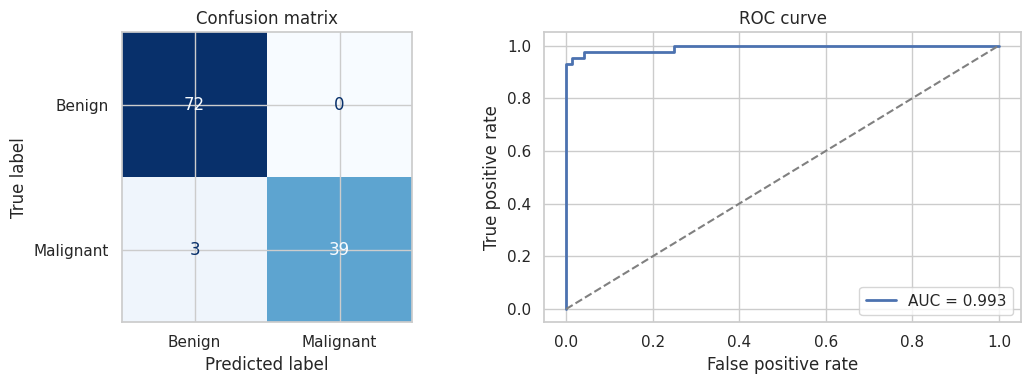

In [10]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Benign","Malignant"], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Benign","Malignant"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion matrix")
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax[1].plot([0,1],[0,1],"--",color="grey"); ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend()
plt.tight_layout(); plt.show()

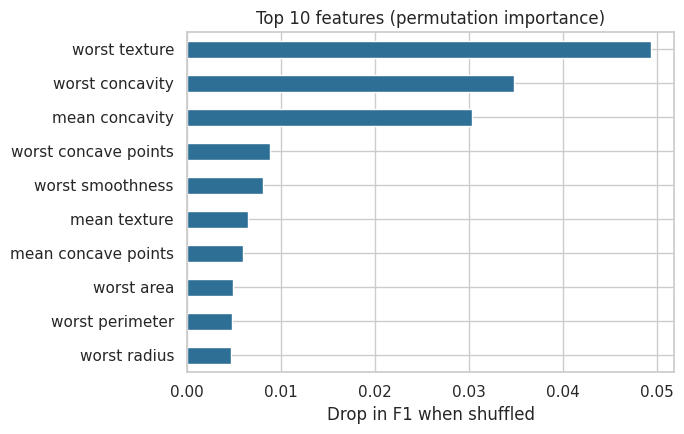

In [11]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=20, scoring="f1", random_state=RANDOM_STATE)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4.5))
imp[::-1].plot.barh(color="#2E6F95")
plt.title("Top 10 features (permutation importance)"); plt.xlabel("Drop in F1 when shuffled")
plt.tight_layout(); plt.show()

In [12]:
# Error analysis: which test cases did the model get wrong?
errors = X_test.copy()
errors["actual"] = y_test.values; errors["predicted"] = y_pred; errors["p_malignant"] = y_prob.round(3)
errors[errors.actual != errors.predicted][["actual","predicted","p_malignant","worst radius","worst concave points"]]

,actual,predicted,p_malignant,worst radius,worst concave points
99,1,0,0.422,16.33,0.1565
73,1,0,0.025,16.57,0.1383
205,1,0,0.260,17.77,0.1252
